In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("interpreter:", sys.executable)

Python: 3.13.7
pandas: 3.0.5
numpy: 2.4.6
scikit-learn: 1.9.1
interpreter: C:\Users\ayomi\Projects\serious stuff\BTT\Flow-1A-responsible-ai-prototype-for-personalized-neighborhood-recommendations\.venv\Scripts\python.exe


## Data audit: Task #2 

Per the milestone doc, this task requires: 
- (1) row/column counts + dtypes for all four starter CSVs, 
- (2) reconciling columns against `data_dictionary.md` in both directions, 
- (3) confirming the anchor ZIPs (33127/33128/33130) appear in every file, and 
- (4) noting which columns are real vs. blended vs. synthetic. 

The `scripts/validate_data.py` only covers (1) and (3), this jupyter notebook cell below fills in (2) and (4) as well.

In [2]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("..") / "data"
ANCHOR_ZIPS = {33127, 33128, 33130}

csv_files = sorted(DATA_DIR.glob("*.csv"))
dataframes = {f.name: pd.read_csv(f) for f in csv_files}

print("CSV files:")
for name in dataframes:
    print(" -", name)

print("\n--------------------------")
for name, df in dataframes.items():
    print(f"{name}:")
    print(f"\tRows: {df.shape[0]}")
    print(f"\tColumns: {df.shape[1]}")
    print("\tDtypes:")
    print(df.dtypes.to_string())
    if "zip" in df.columns:
        found = ANCHOR_ZIPS & set(df["zip"])
        print(f"\tAnchor ZIPs present ({len(found)}/3): {sorted(found)}")
    print()

# documented columns per file, transcribed from data_dictionary.md, for a
# two-way reconciliation against what's actually in each CSV - for certainty.
DOCUMENTED_COLUMNS = {
    "miami_dade_public_features.csv": {
        "NAME", "B01003_001E", "B25064_001E", "B25077_001E", "B07003_001E",
        "B07003_004E", "B07003_008E", "B07003_010E", "B11016_001E",
        "B25003_002E", "B25003_003E", "zip", "moved_different_house_pct",
        "median_rent_usd", "population", "zillow_home_value_index",
        "zillow_rent_index",
    },
    "area_features.csv": {
        "zip", "area_name", "rent_band", "transit", "social", "quiet",
        "pet_friendly", "walkable", "migration_score", "median_rent_usd",
        "co_living_friendly",
    },
    "area_options.csv": {
        "option_id", "zip", "rent_band", "housing_preference", "household",
        "tags", "summary", "disclaimer",
    },
    "crowd_text_snippets.csv": {
        "snippet_id", "zip", "source", "theme", "text",
    },
}

# File-level real/blended/synthetic classification, per data_dictionary.md's
# own descriptions (no per-column source tagging exists in the data yet).
DATA_PROVENANCE = {
    "miami_dade_public_features.csv": "real (Census ACS + Zillow-style indices)",
    "area_features.csv": "blended (real rent/migration fields + derived preference-proxy scores)",
    "area_options.csv": "synthetic (demo cards, NOT REAL LISTINGS)",
    "crowd_text_snippets.csv": "demo (snippets mimicking review/forum text, to be replaced with a real corpus)",
}

print("--------------------------")
print("Reconciliation against data_dictionary.md:\n")
for name, df in dataframes.items():
    actual = set(df.columns)
    documented = DOCUMENTED_COLUMNS.get(name, set())
    missing_from_dict = actual - documented
    missing_from_csv = documented - actual
    print(f"{name}  [{DATA_PROVENANCE.get(name, 'unclassified')}]")
    print(f"\tIn CSV but not documented: {sorted(missing_from_dict) or 'none'}")
    print(f"\tDocumented but not in CSV: {sorted(missing_from_csv) or 'none'}")
    print()

CSV files:
 - area_features.csv
 - area_features_clean.csv
 - area_options.csv
 - crowd_text_snippets.csv
 - miami_dade_public_features.csv
 - miami_dade_public_features_clean.csv

--------------------------
area_features.csv:
	Rows: 80
	Columns: 12
	Dtypes:
zip                         int64
area_name                     str
rent_band                     str
transit                   float64
social                    float64
quiet                     float64
pet_friendly              float64
walkable                  float64
migration_score           float64
median_rent_usd             int64
co_living_friendly        float64
single_family_friendly    float64
	Anchor ZIPs present (3/3): [33127, 33128, 33130]

area_features_clean.csv:
	Rows: 80
	Columns: 13
	Dtypes:
zip                             int64
area_name                         str
rent_band                         str
transit                       float64
social                        float64
quiet                         float

## Suppression handling: Task #3 

Per the milestone doc, this task requires: (1) count suppressed cells per column *and* per ZIP, (2) a documented drop/impute/flag decision per column with rationale, (3) a guarantee that no `-666666666` sentinel reaches the recommender, and (4) a reusable `clean_public_features()`. Prisha's `scripts/clean_data.py` provides the reusable function and the per-column counts/guarantee, this fills in the per-ZIP breakdown and the documented rationale, and calls the real function rather than re-implementing it.

In [3]:
import sys

sys.path.append(str(Path("..").resolve()))
from scripts.clean_data import SUPPRESSED_VALUE, clean_public_features

raw_public_features = dataframes["miami_dade_public_features.csv"]

# Per-ZIP breakdown: which ZIPs carry a suppressed cell, and in which columns.
numeric_cols = raw_public_features.select_dtypes(include="number").columns
suppressed_mask = raw_public_features[numeric_cols] == SUPPRESSED_VALUE
affected_cols = suppressed_mask.columns[suppressed_mask.any()]

print(f"Loaded {len(raw_public_features)} rows")
print(f"\nSuppressed cells per ZIP (columns: {list(affected_cols)}):")
per_zip = raw_public_features.loc[suppressed_mask.any(axis=1), ["zip", *affected_cols]]
print(per_zip.to_string(index=False))

anchor_hit = set(per_zip["zip"]) & ANCHOR_ZIPS
print(f"\nAnchor ZIPs affected by suppression: {sorted(anchor_hit) or 'none'}")

cleaned_public_features, suppression_report = clean_public_features(raw_public_features)

print("\n--------------------------")
print("Per-column decision (documented rationale):")
if suppression_report.empty:
    print("No suppressed cells found.")
else:
    for _, row in suppression_report.iterrows():
        n = row["suppressed_count"]
        n_null = row["null_count"]
        pct = 100 * (n + n_null) / len(raw_public_features)
        print(
            f"\t{row['column']}: {n} suppressed + {n_null} null cell(s) ({pct:.1f}% of ZIPs) "
            f"-> flag with `{row['column']}_suppressed`, impute NaN with the "
            f"column median ({row['imputed_value']:.0f}). Decision: impute rather than "
            f"drop, since <5% of ZIPs are affected and none of the three anchor "
            f"ZIPs (33127/33128/33130) are impacted, so dropping rows would lose "
            f"data for other ZIPs without protecting the profiles we actually "
            f"score against."
        )

leaked = (cleaned_public_features[numeric_cols] == SUPPRESSED_VALUE).any().any()
print(f"\nSentinel value present anywhere in cleaned data: {leaked}")

# Genuine source NaNs (zero-population ZCTAs: industrial/water tracts) are a
# separate cause of missingness from Census suppression. clean_data.py now
# flags them as `<col>_missing` and imputes them too, so both are handled -
# they are reported separately because they mean different things.
genuine_nan_cols = raw_public_features.columns[raw_public_features.isna().any()]
print(f"\nColumns with non-sentinel NaNs (flagged as `<col>_missing`): {list(genuine_nan_cols)}")

cleaned_public_features.head()

Loaded 80 rows

Suppressed cells per ZIP (columns: ['B25064_001E', 'B25077_001E', 'median_rent_usd']):
  zip  B25064_001E  B25077_001E  median_rent_usd
33101   -666666666   -666666666       -666666666
33109   -666666666      2000001       -666666666
33039   -666666666   -666666666       -666666666

Anchor ZIPs affected by suppression: none

--------------------------
Per-column decision (documented rationale):
	B25064_001E: 3 suppressed + 0 null cell(s) (3.8% of ZIPs) -> flag with `B25064_001E_suppressed`, impute NaN with the column median (1663). Decision: impute rather than drop, since <5% of ZIPs are affected and none of the three anchor ZIPs (33127/33128/33130) are impacted, so dropping rows would lose data for other ZIPs without protecting the profiles we actually score against.
	B25077_001E: 2 suppressed + 0 null cell(s) (2.5% of ZIPs) -> flag with `B25077_001E_suppressed`, impute NaN with the column median (380100). Decision: impute rather than drop, since <5% of ZIPs are affect

,NAME,B01003_001E,B25064_001E,B25077_001E,B07003_001E,B07003_004E,B07003_008E,B07003_010E,B11016_001E,B25003_002E,...,median_rent_usd,population,zillow_home_value_index,zillow_rent_index,B25064_001E_suppressed,B25077_001E_suppressed,moved_different_house_pct_missing,median_rent_usd_suppressed,zillow_home_value_index_missing,zillow_rent_index_missing
0,ZCTA5 33101,0,1663.0,380100.0,0,0,0,0,0,0,...,1663.0,0,5.270541e+05,2674.724477,True,True,True,True,True,True
1,ZCTA5 33109,792,1663.0,2000001.0,792,630,97,0,328,307,...,1663.0,792,6.413596e+06,2674.724477,True,False,False,True,False,True
2,ZCTA5 33122,1873,2370.0,1335900.0,1824,962,241,8,816,76,...,2370.0,1873,1.505538e+06,2740.611111,False,False,False,False,False,False
3,ZCTA5 33125,54873,1238.0,339300.0,54290,49530,2057,171,21227,5080,...,1238.0,54873,4.597721e+05,2313.579167,False,False,False,False,False,False
4,ZCTA5 33126,46798,1546.0,287100.0,46403,41635,1763,240,18073,7104,...,1546.0,46798,3.017829e+05,2380.241026,False,False,False,False,False,False


## EDA: Task #4

Per the milestone doc, Task #4 is: **"EDA on the three anchor ZIPs, distributions, correlation matrix, flag near-duplicate and proxy-risk features, save 3-5 charts reusable in the final presentation."**

Scope note: this section *flags* problems, it does not fix them. Choosing what to drop, rescale or combine is Task #5 (feature schema); modelling is Task #6.

`scripts/eda.py` holds every check and chart builder below as a small reusable function (same shape as `clean_data.py`: a DataFrame or a Matplotlib `Figure` in, nothing hidden), so Task #5 and Task #6 can re-run or extend any of it instead of re-deriving it.

**ZIP dtype boundary:** the Task #2/#3 cells above read the CSVs with plain `read_csv`, so their `zip` is `int64`. `eda.load_data()` pins `zip` to `str` and `eda.ANCHOR_ZIPS` is keyed by string. Everything below uses the string convention consistently. The two halves never join to each other, so this is safe today, but any future merge across that line must cast first.

### 1. Inspect: first look at each file

In [4]:
%matplotlib inline

import matplotlib.pyplot as plt

from scripts import eda

bundle = eda.load_data(data_dir=DATA_DIR)
clean_area = pd.read_csv(DATA_DIR / "area_features_clean.csv", dtype={"zip": str})

for name, df in dataframes.items():
    print(f"--- {name}  (shape={df.shape}) ---")
    print(df.sample(min(3, len(df)), random_state=0).to_string(index=False))
    print()

--- area_features.csv  (shape=(80, 12)) ---
  zip    area_name rent_band  transit   social    quiet  pet_friendly  walkable  migration_score  median_rent_usd  co_living_friendly  single_family_friendly
33166        Doral 1200-1800 0.661232 0.370864 0.814568           0.6  0.999997         0.349659             1655            0.362382                    0.65
33150 Little Haiti 1200-1800 1.000000 0.447431 0.776284           0.6  0.999996         0.287845             1094            0.383597                    0.65
33156    Pinecrest 1800-2200 0.570610 0.458333 0.770833           0.6  0.999998         0.236239             1918            0.369496                    0.92

--- area_features_clean.csv  (shape=(80, 13)) ---
  zip    area_name rent_band  transit   social    quiet  pet_friendly  walkable  migration_score  median_rent_usd  co_living_friendly  single_family_friendly  median_rent_usd_suppressed
33166        Doral 1200-1800 0.661232 0.370864 0.814568           0.6  0.999997        

### 2. Describe: summary statistics

Always before any chart: `.describe()` on the numeric columns.

In [5]:
print("=== area_features.csv ===")
print(eda.describe_numeric(bundle.area_features).round(2).to_string())
print(
    "\nmedian_rent_usd's mean is ~-25,000,000 with a min of -666,666,666 -- that's the Census\n"
    "suppression sentinel from Task #3, present in the RAW area_features.csv. describe() catches\n"
    "it before a single chart is drawn, which is the point of running it first."
)

=== area_features.csv ===
                        count         mean           std           min      25%      50%      75%      max
transit                  80.0         0.65  2.000000e-01  0.000000e+00     0.57     0.67     0.78     1.00
social                   80.0         0.52  2.600000e-01  0.000000e+00     0.33     0.52     0.76     1.00
quiet                    80.0         0.76  1.300000e-01  5.000000e-01     0.67     0.77     0.86     1.00
pet_friendly             80.0         0.60  0.000000e+00  6.000000e-01     0.60     0.60     0.60     0.60
walkable                 80.0         0.96  1.900000e-01  0.000000e+00     1.00     1.00     1.00     1.00
migration_score          80.0         0.27  1.600000e-01  0.000000e+00     0.18     0.23     0.31     1.00
median_rent_usd          80.0 -24998310.56  1.274551e+08 -6.666667e+08  1447.00  1653.50  1913.50  3501.00
co_living_friendly       80.0         0.43  1.700000e-01  1.500000e-01     0.32     0.43     0.55     0.92
single_fami

### 3. Missingness

Genuine NaNs only. The suppression sentinel is a valid-looking int, not a NaN, so it never appears here, Step 5 covers that separately.

In [6]:
for name, df in dataframes.items():
    report = eda.missingness_report(df)
    flagged = report[report["n_missing"] > 0]
    print(f"{name}: {len(flagged)} column(s) with missing values")
    if not flagged.empty:
        print(flagged.to_string(index=False))
    print()

area_features.csv: 0 column(s) with missing values

area_features_clean.csv: 0 column(s) with missing values

area_options.csv: 0 column(s) with missing values

crowd_text_snippets.csv: 0 column(s) with missing values

miami_dade_public_features.csv: 3 column(s) with missing values
                   column   dtype  n_missing  pct_missing  n_unique
moved_different_house_pct float64          2          2.5        78
  zillow_home_value_index float64          2          2.5        78
        zillow_rent_index float64          6          7.5        74

miami_dade_public_features_clean.csv: 0 column(s) with missing values



### 4. Distributions

Raw distributions first, warts and all. The anchor-focused, presentation-ready versions come in Step 7.

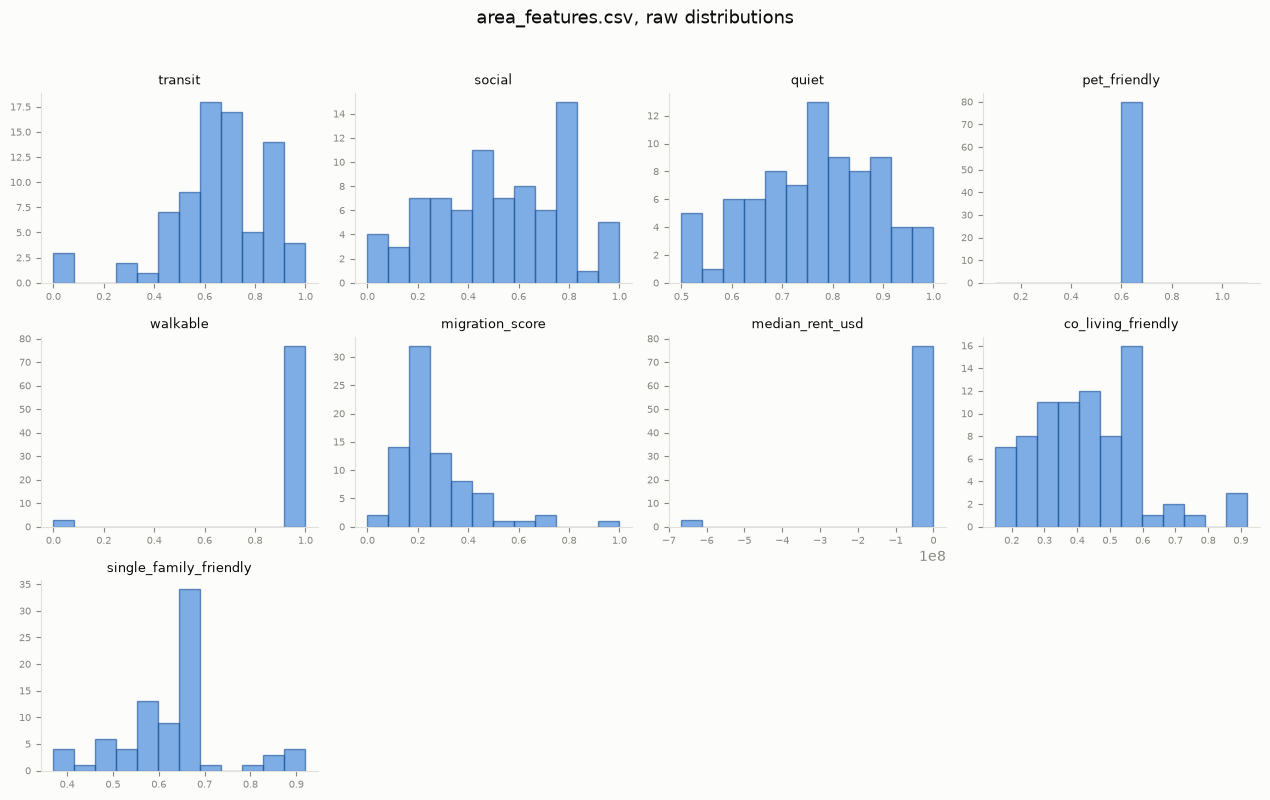

median_rent_usd's single bar near -6.7e8 is the suppression sentinel again.
Note walkable and pet_friendly: both are a single spike. Step 5 explains why.


In [7]:
numeric_area_cols = bundle.area_features.select_dtypes(include="number").columns.tolist()
fig = eda.plot_numeric_distributions(
    bundle.area_features, numeric_area_cols, "area_features.csv, raw distributions"
)
plt.show()
print(
    "median_rent_usd's single bar near -6.7e8 is the suppression sentinel again.\n"
    "Note walkable and pet_friendly: both are a single spike. Step 5 explains why."
)

### 5. Degenerate features: constant and near-constant

**This is the most consequential finding in Task #4.**

`constant_columns()` tests `std <= 1e-9`, which catches `pet_friendly` (a flat 0.6) but *misses* `walkable`, whose std is 0.19. That std is carried entirely by three outliers. `near_constant_columns()` tests the 5th-95th percentile spread instead, which is the right instrument for a column that is flat across the bulk of its rows but has a few extreme values.

In [8]:
print("=== Zero-variance columns (std <= 1e-9) ===")
print("area_features.csv:", eda.constant_columns(bundle.area_features) or "none")

print("\n=== Near-constant columns (middle 90% spans < 1e-3) ===")
for label, df in (("area_features.csv", bundle.area_features), ("area_features_clean.csv", clean_area)):
    print(f"\n{label}:")
    print(eda.near_constant_columns(df).to_string(index=False))

# Why walkable is degenerate: it is min_max_norm(median_rent_usd) computed
# while the -666666666 sentinel was still in the rent column, so the sentinel
# became the normalisation floor.
rent = bundle.area_features["median_rent_usd"]
predicted = (rent - rent.min()) / (rent.max() - rent.min())
print("\n=== Derivation proof ===")
print("max |walkable - min_max_norm(rent_with_sentinel)|:",
      float((bundle.area_features["walkable"] - predicted).abs().max()))

real = bundle.area_features[rent != SUPPRESSED_VALUE]
print(f"\nwalkable across the {len(real)} non-suppressed ZIPs: "
      f"min={real['walkable'].min():.6f} max={real['walkable'].max():.6f} "
      f"spread={float(real['walkable'].max() - real['walkable'].min()):.2e}")
print("walkable for the 3 suppressed ZIPs:",
      bundle.area_features.loc[rent == SUPPRESSED_VALUE, "walkable"].tolist())

print("\n=== Does cleaning fix it? ===")
print("clean file still has walkable == 0.0 for ZIPs:",
      clean_area.loc[clean_area["walkable"] == 0.0, "zip"].tolist())
print("r(walkable, rent) raw  :", round(bundle.area_features["walkable"].corr(rent), 4))
print("r(walkable, rent) clean:", round(clean_area["walkable"].corr(clean_area["median_rent_usd"]), 4))
print(
    "\nclean_data.py repairs median_rent_usd but does not recompute the column derived from it.\n"
    "So walkable has decayed from 'duplicate of rent' to 'noise': 77 identical values plus 3\n"
    "now-meaningless zeros. It encodes suppression status, never walkability.\n"
    "Task #5 must recompute it from cleaned rent or drop it. It cannot be used as-is."
)

=== Zero-variance columns (std <= 1e-9) ===
area_features.csv: ['pet_friendly']

=== Near-constant columns (middle 90% spans < 1e-3) ===

area_features.csv:
      column  p5_p95_spread  full_range  dominant_value_share
pet_friendly       0.000000         0.0                 1.000
    walkable       0.000002         1.0                 0.625

area_features_clean.csv:
      column  p5_p95_spread  full_range  dominant_value_share
pet_friendly       0.000000         0.0                 1.000
    walkable       0.000002         1.0                 0.625

=== Derivation proof ===
max |walkable - min_max_norm(rent_with_sentinel)|: 1.1102230246251565e-16

walkable across the 77 non-suppressed ZIPs: min=0.999996 max=1.000000 spread=3.61e-06
walkable for the 3 suppressed ZIPs: [0.0, 0.0, 0.0]

=== Does cleaning fix it? ===
clean file still has walkable == 0.0 for ZIPs: ['33101', '33109', '33039']
r(walkable, rent) raw  : 1.0
r(walkable, rent) clean: 0.0391

clean_data.py repairs median_rent_usd 

### 6. Correlation matrix & redundancy

Three distinct things, deliberately reported separately, a single correlation matrix hides the difference:

1. **Exact duplicates**: byte-identical columns.
2. **Correlated pairs**: genuinely related but distinct measures.
3. **Pearson vs Spearman**: several features here are bounded to [0, 1] or near-degenerate, where Pearson is easy to misread. `walkable`'s r = 1.00 against rent was technically true and told entirely the wrong story.

Chart 1 of 5 for the presentation.

=== Exact duplicate columns (miami_dade_public_features.csv) ===
[('B01003_001E', 'population'), ('B25064_001E', 'median_rent_usd')]

=== Correlated pairs, |r| >= 0.7 (area_features.csv) ===
   col_a              col_b  pearson  spearman
walkable    median_rent_usd    1.000     1.000
  social              quiet   -0.825    -0.773
  social co_living_friendly    0.778     0.895

=== Correlated pairs, |r| >= 0.7 (miami_dade_public_features.csv) ===
          col_a                   col_b  pearson  spearman
    B01003_001E             B07003_001E    1.000     1.000
    B25064_001E         median_rent_usd    1.000     1.000
    B01003_001E              population    1.000     1.000
    B07003_001E              population    1.000     1.000
    B01003_001E             B07003_004E    0.994     0.991
    B07003_004E              population    0.994     0.991
    B07003_001E             B07003_004E    0.994     0.992
    B01003_001E             B11016_001E    0.943     0.944
    B07003_001E    

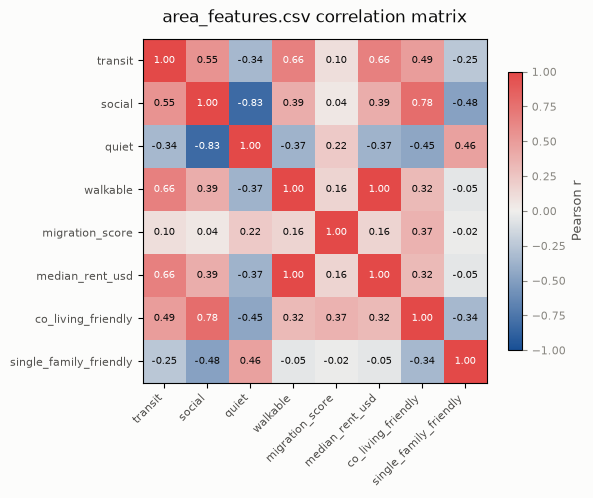

In [9]:
print("=== Exact duplicate columns (miami_dade_public_features.csv) ===")
print(eda.exact_duplicate_columns(bundle.public_features) or "none")

for label, df in (
    ("area_features.csv", bundle.area_features),
    ("miami_dade_public_features.csv", bundle.public_features),
):
    print(f"\n=== Correlated pairs, |r| >= 0.7 ({label}) ===")
    pairs = eda.correlated_pairs(df, threshold=0.7)
    if pairs.empty:
        print("none")
        continue
    numeric = df.select_dtypes(include="number")
    pairs = pairs.rename(columns={"r": "pearson"})
    pairs["spearman"] = [
        round(float(numeric[a].corr(numeric[b], method="spearman")), 3)
        for a, b in zip(pairs["col_a"], pairs["col_b"])
    ]
    print(pairs.to_string(index=False))

fig = eda.plot_correlation_heatmap(bundle.area_features, "area_features.csv correlation matrix")
eda.save_fig(fig, "01_area_features_correlation_heatmap")
plt.show()

### 7. Anchor ZIP profile

**Caveat: n = 3.** Everything in this section is descriptive comparison of three specific ZIPs, not evidence of a broader neighbourhood pattern. Nothing here supports a statistical claim.

Charts 2 and 3 of 5.

  zip area_label rent_band  median_rent_usd  transit  social    quiet  pet_friendly  walkable
33127    Wynwood 1200-1800             1283 0.852804     0.8 0.800909           0.6  0.999997
33128   Downtown 1200-1800             1191 0.918624     0.8 0.936776           0.6  0.999997
33130   Brickell 1200-1800             1553 0.850000     0.8 0.768273           0.6  0.999997

All three anchors share the rent_band bucket '1200-1800' and sit at walkable=0.999997,
so neither field discriminates between them. Only continuous median_rent_usd and the
Zillow indices actually separate the three.


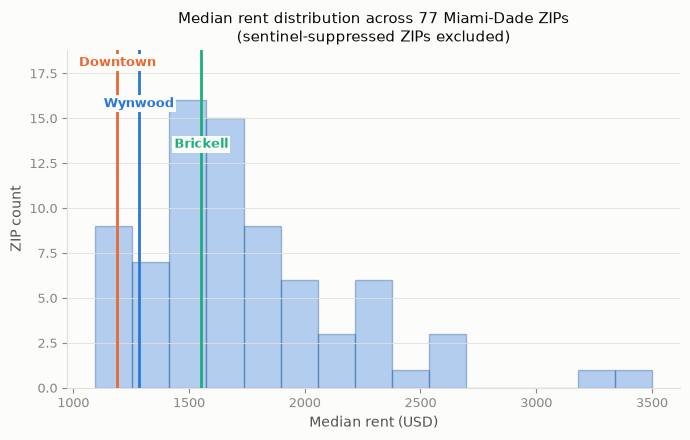

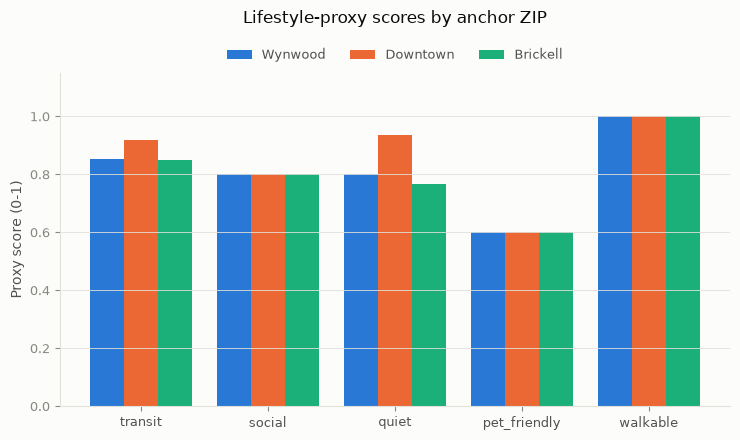

Two of the five bars in this chart are not real signal: pet_friendly is constant at 0.6
for every ZIP, and walkable is pinned at ~1.0 for every non-suppressed ZIP (Step 5).


In [10]:
profile_cols = ["rent_band", "median_rent_usd", "transit", "social", "quiet", "pet_friendly", "walkable"]
print(eda.anchor_zip_profile(bundle.area_features, profile_cols).to_string(index=False))
print(
    "\nAll three anchors share the rent_band bucket '1200-1800' and sit at walkable=0.999997,\n"
    "so neither field discriminates between them. Only continuous median_rent_usd and the\n"
    "Zillow indices actually separate the three."
)

fig = eda.plot_rent_distribution(bundle.area_features)
eda.save_fig(fig, "02_anchor_rent_distribution")
plt.show()

fig = eda.plot_anchor_lifestyle_comparison(
    bundle.area_features, ["transit", "social", "quiet", "pet_friendly", "walkable"]
)
eda.save_fig(fig, "03_anchor_lifestyle_comparison")
plt.show()
print(
    "Two of the five bars in this chart are not real signal: pet_friendly is constant at 0.6\n"
    "for every ZIP, and walkable is pinned at ~1.0 for every non-suppressed ZIP (Step 5)."
)

### 8. NLP corpus coverage

Chart 4 of 5: how thin and lopsided the crowd-text corpus is.

        theme  snippet_count
       social              6
        quiet              3
    co_living              3
single_family              3
      transit              3
 pet_friendly              1
    expensive              1

Total snippets: 20 across 7 themes, for 80 ZIPs.

  zip area_label     theme  snippet_count
33127    Wynwood co_living              1
33127    Wynwood    social              1
33127    Wynwood   transit              1
33128   Downtown co_living              1
33128   Downtown    social              1
33128   Downtown   transit              1
33130   Brickell co_living              1
33130   Brickell     quiet              1
33130   Brickell    social              1
33130   Brickell   transit              1


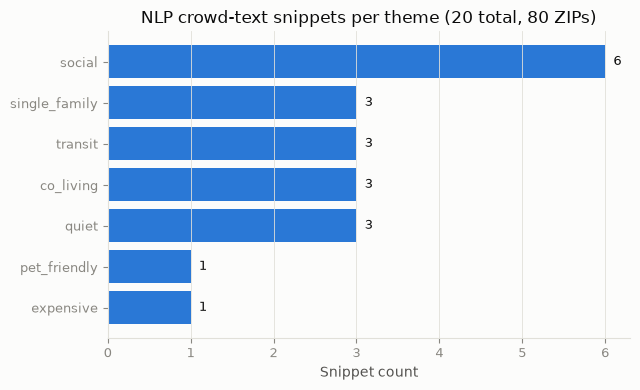

The corpus is underpowered: 20 snippets over 7 themes, and 2 of the 3 anchors have zero
quiet-themed snippets despite quiet being a lifestyle tag. Any Task #6 metric built on
theme coverage will be noisy at this sample size - treat it as directional only.


In [11]:
totals = eda.theme_totals(bundle.crowd_text)
print(totals.to_string(index=False))
print(
    f"\nTotal snippets: {int(totals['snippet_count'].sum())} across {len(totals)} themes, "
    f"for {bundle.area_features['zip'].nunique()} ZIPs."
)
print()
print(eda.anchor_theme_coverage(bundle.crowd_text).to_string(index=False))

fig = eda.plot_theme_totals(bundle.crowd_text)
eda.save_fig(fig, "04_nlp_theme_coverage")
plt.show()
print(
    "The corpus is underpowered: 20 snippets over 7 themes, and 2 of the 3 anchors have zero\n"
    "quiet-themed snippets despite quiet being a lifestyle tag. Any Task #6 metric built on\n"
    "theme coverage will be noisy at this sample size - treat it as directional only."
)

### 9. Demographic-proxy risk

No race or ethnicity field exists anywhere in this data. That does not make the feature set neutral: housing-market variables can encode socioeconomic structure, and in a historically segregated metro that structure is not independent of demographics.

This is an analytical caution for the responsible-AI write-up, not a causal claim about any ZIP or its residents. Chart 5 of 5.

  zip area_label  renter_share
33127    Wynwood      0.708208
33128   Downtown      0.968518
33130   Brickell      0.874667


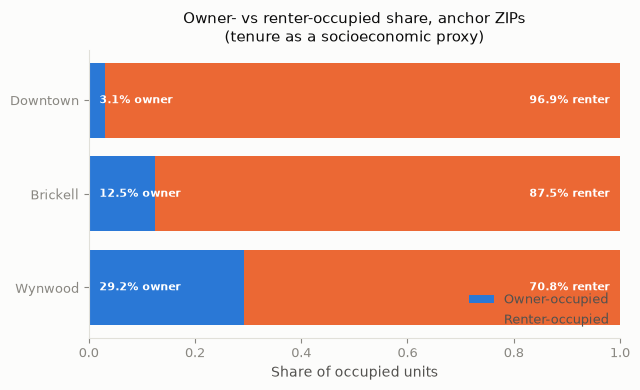

Proxy-risk features to carry into the Task #5 schema discussion:
  - tenure mix (B25003_002E / B25003_003E) - the starkest of the three
  - median_rent_usd and zillow_rent_index
  - B25077_001E home value and zillow_home_value_index
None are demographic fields. All can stand in for socioeconomic position.


In [12]:
tenure = bundle.public_features[bundle.public_features["zip"].isin(eda.ANCHOR_ZIPS)][
    ["zip", "B25003_002E", "B25003_003E"]
].copy()
tenure["area_label"] = tenure["zip"].map(eda.ANCHOR_ZIPS)
tenure["renter_share"] = tenure["B25003_003E"] / (tenure["B25003_002E"] + tenure["B25003_003E"])
print(tenure[["zip", "area_label", "renter_share"]].to_string(index=False))

fig = eda.plot_anchor_tenure_mix(bundle.public_features)
eda.save_fig(fig, "05_anchor_tenure_mix")
plt.show()
print(
    "Proxy-risk features to carry into the Task #5 schema discussion:\n"
    "  - tenure mix (B25003_002E / B25003_003E) - the starkest of the three\n"
    "  - median_rent_usd and zillow_rent_index\n"
    "  - B25077_001E home value and zillow_home_value_index\n"
    "None are demographic fields. All can stand in for socioeconomic position."
)

### 10. `area_options.csv` coverage, and the co-leaser guardrail

`co_leaser` and `co_living` are different concepts and neither may be inferred from the other (see `README.md`): a couple on one private lease is not someone seeking a stranger-roommate setup. The valid combination list below encodes that rule, `with_co_leaser` + `co_living` is intentionally absent and must stay absent.

These are synthetic demo cards, not real listings.

In [13]:
valid_combos = [
    ("alone", "own_apartment"),
    ("alone", "co_living"),
    ("with_co_leaser", "own_apartment"),
]
coverage = eda.option_combo_coverage(bundle.area_options, valid_combos)
print(coverage.to_string(index=False))

present = set(map(tuple, bundle.area_options[["household", "housing_preference"]].values))
print(
    "\nGuardrail check - 'with_co_leaser' + 'co_living' absent from the data:",
    ("with_co_leaser", "co_living") not in present,
)
print("\nMissing combos per anchor:")
for (zip_code, label), grp in coverage[~coverage["present"]].groupby(["zip", "area_label"]):
    combos = ", ".join(f"{h} + {p}" for h, p in zip(grp["household"], grp["housing_preference"]))
    print(f"  {label} ({zip_code}): {combos}")

  zip area_label      household housing_preference  present
33127    Wynwood          alone      own_apartment     True
33127    Wynwood          alone          co_living    False
33127    Wynwood with_co_leaser      own_apartment     True
33128   Downtown          alone      own_apartment    False
33128   Downtown          alone          co_living     True
33128   Downtown with_co_leaser      own_apartment     True
33130   Brickell          alone      own_apartment    False
33130   Brickell          alone          co_living     True
33130   Brickell with_co_leaser      own_apartment     True

Guardrail check - 'with_co_leaser' + 'co_living' absent from the data: True

Missing combos per anchor:


  Wynwood (33127): alone + co_living
  Downtown (33128): alone + own_apartment
  Brickell (33130): alone + own_apartment


### Takeaways for Task #5 (feature schema) and Task #6 (recommender)

Flags only, the decisions below belong to Task #5.

- **`walkable` is unusable as-is: recompute it from cleaned rent, or drop it.** It is `min_max_norm(median_rent_usd)` computed while the `-666666666` sentinel was still in the rent column, so 3 suppressed ZIPs got `0.0` and the other 77 were squashed into a 4e-06 band around 1.0. It encodes suppression status, not walkability. Cleaning rent does **not** recompute it, so `area_features_clean.csv` still carries the broken column. Recomputed, it would be an honest duplicate of rent: still not an independent signal.
- **Read `data/area_features_clean.csv`, not the raw `area_features.csv`.** The raw file still holds the sentinel for 3 ZIPs (none of them anchors) and would corrupt any scaling fit over the full 80-ZIP set.
- **Drop or re-derive `pet_friendly`.** Constant at 0.6 for all 80 ZIPs, and 1 of 20 snippets in the NLP corpus. It contributes nothing on either side.
- **Don't treat `social`/`quiet` (r = -0.83) or `social`/`co_living_friendly` (r = 0.78) as independent dimensions.** Unlike `walkable`, these are genuinely redundant rather than broken.
- **`population` and `B01003_001E` are byte-identical**; `median_rent_usd` and `B25064_001E` are duplicates by design.
- **`rent_band` cannot separate the three anchors**: all share the `1200-1800` bucket. Use continuous rent for anything that must tell them apart.
- **Budget for NLP noise this cycle.** 20 snippets, 7 themes, and 2 of 3 anchors have no `quiet` snippet.
- **Proxy risk: tenure mix, rent, and home value.** Downtown is 96.9% renter-occupied vs Wynwood's 70.8%. Worth stating in the responsible-AI write-up whether or not these become model features.
- **`area_options.csv` combo coverage is sparse per anchor**: worth checking against Task #9's eval profiles so the gaps aren't baked into the test set.